In [224]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [225]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [226]:
#read dataset
spotify_2024 = pd.read_csv('/content/drive/MyDrive/raw_data/spotify_2024.csv', encoding = 'latin1')

spotify_2024.shape
spotify_2024.columns
spotify_2024.info()
spotify_2024.describe()
spotify_2024.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTok Posts                3427 

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [227]:
#cleaning data
cols = ["All Time Rank", "Spotify Streams", "Spotify Playlist Reach", "Spotify Playlist Count",
        "YouTube Views",
        "YouTube Likes", "TikTok Posts", "TikTok Likes", "TikTok Views",
        "YouTube Playlist Reach", "AirPlay Spins", "Deezer Playlist Reach",
        "Pandora Streams", "Pandora Track Stations", "Soundcloud Streams",
        "Shazam Counts"]

for col in cols:
  # Only apply .str accessor if the column is of object (string) dtype
  if spotify_2024[col].dtype == 'object':
    spotify_2024[col] = spotify_2024[col].str.replace(',', '')
    spotify_2024[col] = spotify_2024[col].astype(float)

#converting data type to datetime
spotify_2024['Release Date'] = pd.to_datetime(spotify_2024['Release Date'])

for col in cols:
  if spotify_2024[col].dtype == 'object':
    spotify_2024[col] = spotify_2024[col].str.replace(',', '')
    spotify_2024[col] = spotify_2024[col].astype(float)
spotify_2024.info()

if 'ISRC' in spotify_2024:
  spotify_2024 = spotify_2024.drop(columns=['ISRC'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Track                       4600 non-null   object        
 1   Album Name                  4600 non-null   object        
 2   Artist                      4595 non-null   object        
 3   Release Date                4600 non-null   datetime64[ns]
 4   ISRC                        4600 non-null   object        
 5   All Time Rank               4600 non-null   float64       
 6   Track Score                 4600 non-null   float64       
 7   Spotify Streams             4487 non-null   float64       
 8   Spotify Playlist Count      4530 non-null   float64       
 9   Spotify Playlist Reach      4528 non-null   float64       
 10  Spotify Popularity          3796 non-null   float64       
 11  YouTube Views               4292 non-null   float64     

In [228]:
if 'TIDAL Popularity' in spotify_2024:
  spotify_2024 = spotify_2024.drop(columns=['TIDAL Popularity'])

if 'Explicit Track' in spotify_2024:
  spotify_2024 = spotify_2024.drop(columns=['Explicit Track'])

In [229]:
#Handling missing value
spotify_2024.isnull().sum()
spotify_2024['Spotify Streams'] = spotify_2024['Spotify Streams'].fillna(0)
spotify_2024.isnull().sum()
cols = ['Spotify Playlist Count', 'Spotify Playlist Reach',
'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts',
'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count',
'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach',
'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams',
'Shazam Counts']

spotify_2024[cols] = spotify_2024[cols].fillna(0)

In [230]:
#Handling duplicate data
checking = spotify_2024.duplicated().sum()
print(checking)
spotify_2024 = spotify_2024.drop_duplicates()
spotify_2024.info()

2
<class 'pandas.core.frame.DataFrame'>
Index: 4598 entries, 0 to 4599
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Track                       4598 non-null   object        
 1   Album Name                  4598 non-null   object        
 2   Artist                      4593 non-null   object        
 3   Release Date                4598 non-null   datetime64[ns]
 4   All Time Rank               4598 non-null   float64       
 5   Track Score                 4598 non-null   float64       
 6   Spotify Streams             4598 non-null   float64       
 7   Spotify Playlist Count      4598 non-null   float64       
 8   Spotify Playlist Reach      4598 non-null   float64       
 9   Spotify Popularity          4598 non-null   float64       
 10  YouTube Views               4598 non-null   float64       
 11  YouTube Likes               4598 non-null   float64       


Track
Danza Kuduro - Cover         2.139445e+10
Cake By The Ocean - Cover    1.293525e+10
Blinding Lights              8.542797e+09
Shape of You                 7.797815e+09
As It Was                    6.601376e+09
Without Me                   6.336157e+09
Flowers                      6.333167e+09
STAY (with Justin Bieber)    6.214201e+09
Kill Bill                    5.590252e+09
Take Me to Church            5.088980e+09
Name: Spotify Streams, dtype: float64


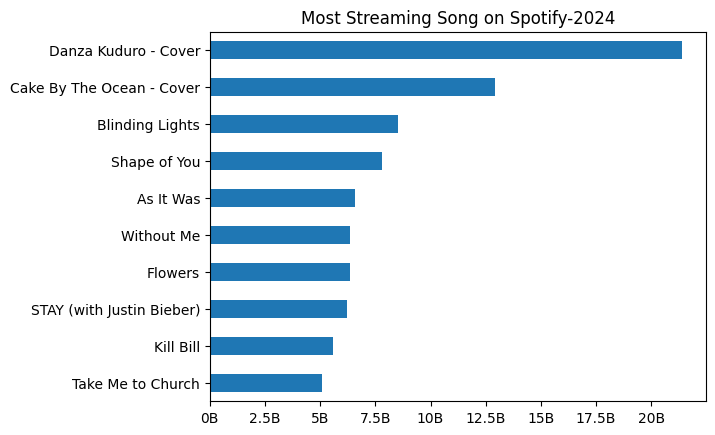

<Figure size 640x480 with 0 Axes>

In [231]:
#Exploratory Data Analysis

#Most Streaming Song on Spotify 2024
top_song = spotify_2024.groupby('Track')['Spotify Streams'].sum()
top_song_2024 = top_song.sort_values(ascending = False)
popular_song = top_song_2024.head(10)
print(popular_song)

popular_song.plot(kind = 'barh')
plt.title('Most Streaming Song on Spotify-2024')
plt.xlabel('')
plt.ylabel('')
plt.xticks([0.00, 0.25e10, 0.50e10, 0.75e10, 1.00e10, 1.25e10, 1.50e10, 1.75e10, 2.00e10],
           ['0B', '2.5B', '5B', '7.5B', '10B', '12.5B', '15B', '17.5B', '20B'])
plt.gca().invert_yaxis()
plt.show()
plt.savefig('popular_song.png')

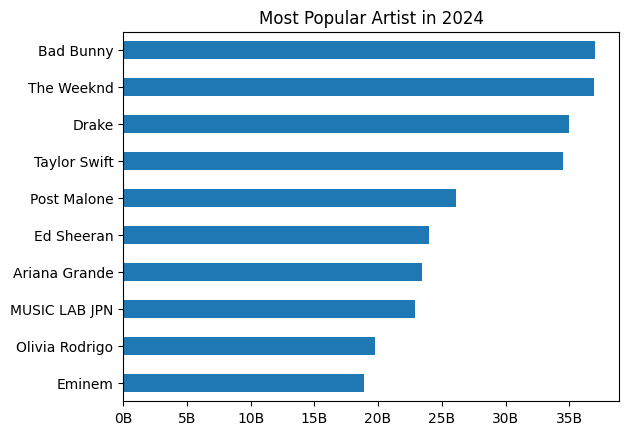

<Figure size 640x480 with 0 Axes>

In [232]:

#Most Popular Artist
most_popular_artist = spotify_2024.groupby('Artist')['Spotify Streams'].sum()
most_popular_artist = most_popular_artist.sort_values(ascending = False)
popular_artist = most_popular_artist.head(10)
popular_artist.plot(kind = 'barh')
plt.title('Most Popular Artist in 2024')
plt.xlabel('')
plt.ylabel('')
plt.xticks([0.0, 0.5e10, 1.0e10, 1.5e10, 2.0e10, 2.5e10, 3.0e10, 3.5e10],
           ['0B', '5B', '10B', '15B', '20B', '25B', '30B', '35B'])
plt.gca().invert_yaxis()
plt.show()
plt.savefig('most_popular_artist.png')

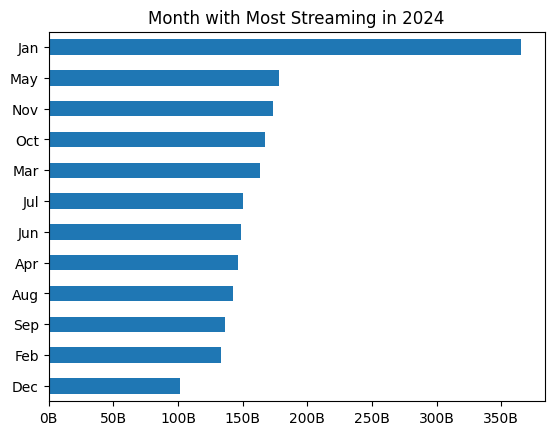

In [233]:
#Month with Most Streaming in 2024
month_map={
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'}

spotify_2024['Month'] = spotify_2024['Release Date'].dt.month
spotify_2024['Month_Name'] = spotify_2024['Month'].map(month_map)
month_streaming = spotify_2024.groupby('Month_Name')['Spotify Streams'].sum()
month_streaming = month_streaming.sort_values(ascending = True)
month_streaming.plot(kind = 'barh')
plt.title('Month with Most Streaming in 2024')
plt.xlabel('')
plt.ylabel('')
plt.xticks([0.0, 0.5e11, 1.0e11, 1.5e11, 2.0e11, 2.5e11, 3.0e11, 3.5e11],
           ['0B', '50B', '100B', '150B', '200B', '250B', '300B', '350B'])
plt.savefig('month_streaming.png')
plt.show()

Correlation Spotify Streams vs Tiktok Views: 0.04402625778963722


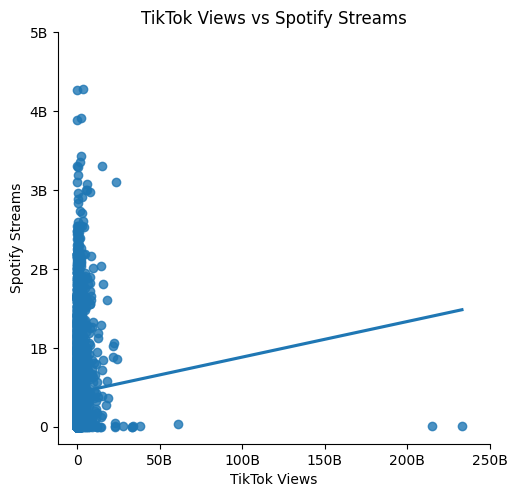

Correlation Spotify Streams vs TikTok Likes: 0.05702474736880293


<Figure size 640x480 with 0 Axes>

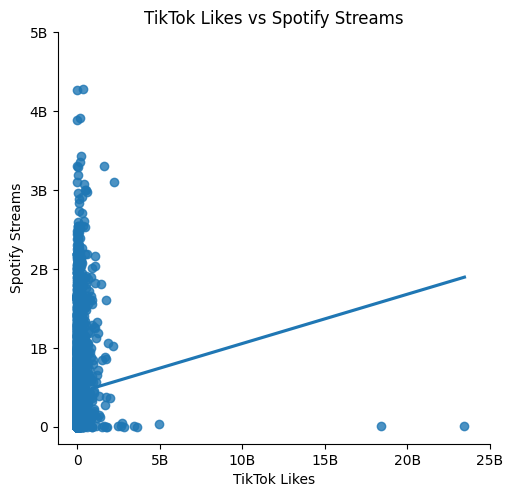

<Figure size 640x480 with 0 Axes>

In [234]:
#Is there correlation Spotify Streams with Other Viral Platform?
streams_vs_tiktokviews_correlation = spotify_2024['Spotify Streams'].corr(spotify_2024['TikTok Views'])
print(f'Correlation Spotify Streams vs Tiktok Views: {streams_vs_tiktokviews_correlation}')
sns.lmplot(data=spotify_2024, x='TikTok Views', y='Spotify Streams', ci = None)
plt.title('TikTok Views vs Spotify Streams')
plt.xticks([0, 0.5e11, 1.0e11, 1.5e11, 2.0e11, 2.5e11],
           ['0', '50B', '100B', '150B', '200B', '250B'])
plt.yticks([0, 1e9, 2e9, 3e9, 4e9, 5e9],
           ['0', '1B', '2B', '3B', '4B', '5B'])
plt.show()
plt.savefig('spotify vs tiktok views.png')

streams_vs_tiktoklikes_correlation = spotify_2024['Spotify Streams'].corr(spotify_2024['TikTok Likes'])
print(f'Correlation Spotify Streams vs TikTok Likes: {streams_vs_tiktoklikes_correlation}')
sns.lmplot(data=spotify_2024, x='TikTok Likes', y='Spotify Streams', ci = None)
plt.title('TikTok Likes vs Spotify Streams')
plt.xticks([0, 0.5e10, 1.0e10, 1.5e10, 2.0e10, 2.5e10],
           ['0', '5B', '10B', '15B', '20B', '25B'])
plt.yticks([0, 1e9, 2e9, 3e9, 4e9, 5e9],
           ['0', '1B', '2B', '3B', '4B', '5B'])
plt.show()
plt.savefig('spotify vs tiktok likes.png')

Correlation Spotify Streams vs Reach: 0.580052335563084


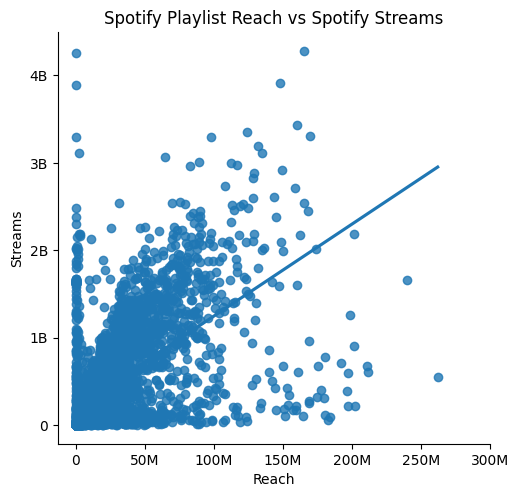

Correlation Spotify Streams vs Count: 0.798055277472161


<Figure size 640x480 with 0 Axes>

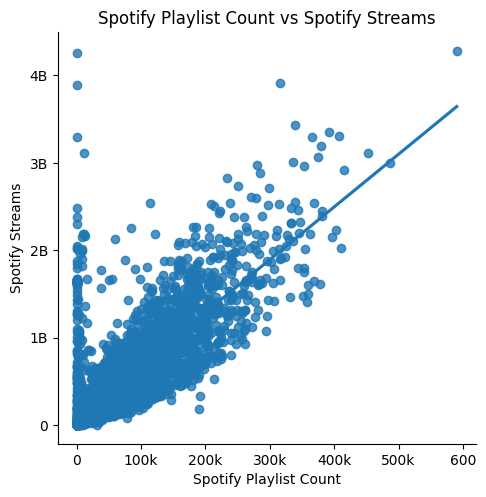

<Figure size 640x480 with 0 Axes>

In [235]:
#How about correlation between Reach and Count with Stpotify Streams?
streams_vs_reach_correlation = spotify_2024['Spotify Streams'].corr(spotify_2024['Spotify Playlist Reach'])
print(f'Correlation Spotify Streams vs Reach: {streams_vs_reach_correlation}')

sns.lmplot(data=spotify_2024, x='Spotify Playlist Reach', y='Spotify Streams', ci = None)
plt.title('Spotify Playlist Reach vs Spotify Streams')
plt.xticks([0, 0.5e8, 1.0e8, 1.5e8, 2.0e8, 2.5e8, 3.0e8],
           ['0', '50M', '100M', '150M', '200M', '250M', '300M'])
plt.yticks([0, 1e9, 2e9, 3e9, 4e9],
           ['0', '1B', '2B', '3B', '4B'])
plt.xlabel('Reach')
plt.ylabel('Streams')
plt.show()
plt.savefig('streams vs reach.png')

streams_vs_count_correlation = spotify_2024['Spotify Streams'].corr(spotify_2024['Spotify Playlist Count'])
print(f'Correlation Spotify Streams vs Count: {streams_vs_count_correlation}')

sns.lmplot(data=spotify_2024, x='Spotify Playlist Count', y='Spotify Streams', ci = None)
plt.title('Spotify Playlist Count vs Spotify Streams')
plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000],
           ['0', '100k', '200k', '300k', '400k', '500k', '600'])
plt.yticks([0, 1e9, 2e9, 3e9, 4e9],
           ['0', '1B', '2B', '3B', '4B'])
plt.show()
plt.savefig('streams vs count.png')